In [ ]:
#------------------------------------------
# Step 1: Environment Setup & GPU Check
#------------------------------------------

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Verify GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
#------------------------------------------
# Step 2: Data Preprocessing & Augmentation
#------------------------------------------

In [2]:
# Data transforms for training (with augmentation) and validation
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], # ImageNet mean values
                             [0.229, 0.224, 0.225])  # ImageNet std values
    ]),
    'val': transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

In [ ]:
#------------------------------------------
# Step 3: Load the Dataset & Create DataLoaders
#------------------------------------------

In [3]:
# Download STL-10 dataset
train_dataset = datasets.STL10(root='./data', split='train', download=True, transform=data_transforms['train'])
val_dataset = datasets.STL10(root='./data', split='test', download=True, transform=data_transforms['val'])

# DataLoaders for batch processing
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

classes = train_dataset.classes
print(f"Classes ({len(classes)}): {classes}")


100%|██████████| 2.64G/2.64G [04:25<00:00, 9.93MB/s]


Classes (10): ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [ ]:
#------------------------------------------
# Step 4: Build Model via Transfer Learning
#------------------------------------------

In [4]:
# Load pre-trained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze lower convolutional layers
for param in model.parameters():
    param.requires_grad = False

# Replace the output classification layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(classes))

# Move model to GPU
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]


In [6]:
#------------------------------------------
# Step 5: Define Loss Function & Optimizer
#------------------------------------------

In [7]:
# CrossEntropyLoss automatically applies LogSoftmax + NLLLoss
criterion = nn.CrossEntropyLoss()

# Only optimize parameters in the final layer
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [ ]:
#------------------------------------------
# Step 6: Train and Validate the Model
#------------------------------------------

In [8]:




epochs = 5

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_loss, running_corrects = 0.0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()            # Clear previous gradients
        outputs = model(inputs)          # Forward pass
        loss = criterion(outputs, labels)# Compute loss
        loss.backward()                  # Backward pass (gradients)
        optimizer.step()                 # Update weights

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    train_loss = running_loss / len(train_dataset)
    train_acc = running_corrects.double() / len(train_dataset)

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss, val_corrects = 0.0, 0

    with torch.no_grad(): # Disable gradient tracking for speed/memory efficiency
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    val_loss = val_loss / len(val_dataset)
    val_acc = val_corrects.double() / len(val_dataset)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

Epoch 1/5 | Train Loss: 1.1641 Acc: 0.6270 | Val Loss: 0.6614 Acc: 0.7940
Epoch 2/5 | Train Loss: 0.7125 Acc: 0.7606 | Val Loss: 0.5701 Acc: 0.8083
Epoch 3/5 | Train Loss: 0.6250 Acc: 0.7954 | Val Loss: 0.5240 Acc: 0.8277
Epoch 4/5 | Train Loss: 0.5980 Acc: 0.7960 | Val Loss: 0.4867 Acc: 0.8376
Epoch 5/5 | Train Loss: 0.5650 Acc: 0.8026 | Val Loss: 0.4726 Acc: 0.8374


In [ ]:
#------------------------------------------
# Step 7: Inference / Predicting on New Images
#------------------------------------------

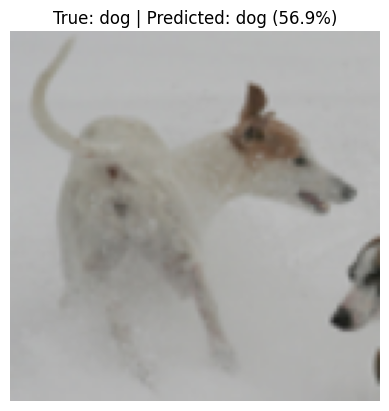

In [16]:
model.eval()

# Grab a single sample batch
dataiter = iter(val_loader)
images, labels = next(dataiter)

# Select first image
img, label = images[2], labels[2]

# Run prediction
with torch.no_grad():
    output = model(img.unsqueeze(0).to(device))
    prob = torch.nn.functional.softmax(output, dim=1)
    pred_class_idx = torch.argmax(prob).item()

# Un-normalize image for visualization
img_display = img.numpy().transpose((1, 2, 0))
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_display = std * img_display + mean
img_display = np.clip(img_display, 0, 1)

plt.imshow(img_display)
plt.title(f"True: {classes[label]} | Predicted: {classes[pred_class_idx]} ({prob[0][pred_class_idx]*100:.1f}%)")
plt.axis("off")
plt.show()

Select an image file from your computer:


Saving truck-car.jpg to truck-car.jpg


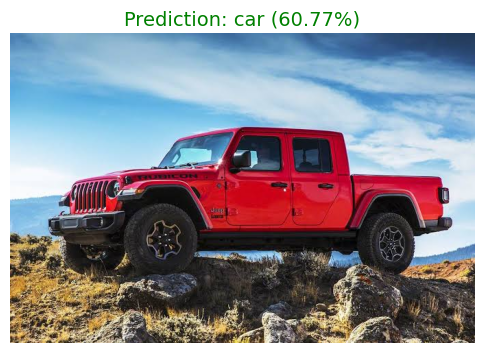


--- Top Predictions ---
1. car: 60.77%
2. truck: 38.36%
3. dog: 0.42%


In [12]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import io
from google.colab import files

# ==========================================
# 1. Define Image Preprocessing Transforms
# ==========================================
# NOTE: These MUST match the dimensions and normalization used during training.
inference_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], # ImageNet mean values
                         [0.229, 0.224, 0.225])  # ImageNet std values
])

# ==========================================
# 2. Upload Image File from Local Machine
# ==========================================
print("Select an image file from your computer:")
uploaded = files.upload()

# Get the filename of the uploaded image
for filename in uploaded.keys():
    # Load raw image file
    raw_image = Image.open(io.BytesIO(uploaded[filename])).convert("RGB")

    # ==========================================
    # 3. Preprocess and Prepare Tensor
    # ==========================================
    # Apply transforms and add batch dimension -> shape: [1, 3, 128, 128]
    input_tensor = inference_transform(raw_image).unsqueeze(0).to(device)

    # ==========================================
    # 4. Predict Class & Softmax Probabilities
    # ==========================================
    model.eval()  # Set model to evaluation mode (disables dropout/batchnorm updates)
    with torch.no_grad():
        logits = model(input_tensor)
        probabilities = F.softmax(logits, dim=1)[0]
        predicted_class_idx = torch.argmax(probabilities).item()

    # Retrieve output labels
    predicted_label = classes[predicted_class_idx]
    confidence = probabilities[predicted_class_idx].item() * 100

    # ==========================================
    # 5. Visualize Results
    # ==========================================
    plt.figure(figsize=(6, 6))
    plt.imshow(raw_image)
    plt.title(f"Prediction: {predicted_label} ({confidence:.2f}%)", fontsize=14, color="green")
    plt.axis("off")
    plt.show()

    # Print top 3 predictions for detailed insight
    top3_prob, top3_idx = torch.topk(probabilities, k=min(3, len(classes)))
    print("\n--- Top Predictions ---")
    for i in range(len(top3_idx)):
        class_name = classes[top3_idx[i].item()]
        prob_percent = top3_prob[i].item() * 100
        print(f"{i+1}. {class_name}: {prob_percent:.2f}%")